In [ ]:
import pandas as pd

In [23]:
train = pd.read_csv('/mnt/disk1/xueying/tmp/antimalaria/trainset_v3.csv')
gen3399 = pd.read_csv('/mnt/disk1/xueying/JAEGER/models/assays/antimalaria/jtvae/jtvae-h-420-l-56-d-7/genchem/GDI-003399/GDI-003399-dir-4-strategy-DeterministicFullGraph-extent-Dense-cutoff-0.2-filter-False-opt_direction-Increase-subset_pca-False.csv')
gen5843 = pd.read_csv('/mnt/disk1/xueying/JAEGER/models/assays/antimalaria/jtvae/jtvae-h-420-l-56-d-7/genchem/GDI-005843/GDI-005843-dir-4-strategy-DeterministicFullGraph-extent-Dense-cutoff-0.2-filter-False-opt_direction-Increase-subset_pca-False.csv')
gen5819 = pd.read_csv('/mnt/disk1/xueying/JAEGER/models/assays/antimalaria/jtvae/jtvae-h-420-l-56-d-7/genchem/GDI-005819/GDI-005819-dir-4-strategy-DeterministicFullGraph-extent-Dense-cutoff-0.2-filter-False-opt_direction-Increase-subset_pca-False.csv')
gen8234 = pd.read_csv('/mnt/disk1/xueying/JAEGER/models/assays/antimalaria/jtvae/jtvae-h-420-l-56-d-7/genchem/GDI-008234/GDI-008234-dir-4-strategy-DeterministicFullGraph-extent-Dense-cutoff-0.2-filter-False-opt_direction-Increase-subset_pca-False.csv')
gen4626 = pd.read_csv('/mnt/disk1/xueying/JAEGER/models/assays/antimalaria/jtvae/jtvae-h-420-l-56-d-7/genchem/GDI-004626/GDI-004626-dir-4-strategy-DeterministicFullGraph-extent-Dense-cutoff-0.2-filter-False-opt_direction-Increase-subset_pca-False.csv')

In [ ]:
train.shape, gen3399.shape, gen5843.shape, gen5819.shape, gen8234.shape, gen4626.shape

In [ ]:
al = pd.concat([gen3399, gen5843, gen5819, gen8234,gen4626], ignore_index=True)
al.shape

In [ ]:
al.to_csv('/mnt/disk1/xueying/JAEGER/models/assays/Novartis_GNF/gen_merge.csv', index=False)

In [11]:
al_rm = al[al['sim'] < 1]
al_rm.shape

(28, 12)

In [12]:
al_rm.to_csv('/mnt/disk1/xueying/JAEGER/models/assays/Novartis_GNF/gen_merge_rmsource.csv', index=False)

/home/xueying/anaconda3/envs/jaeger/lib/python3.9/site-packages/scipy/stats/_distn_infrastructure.py:1988: RuntimeWarning: divide by zero encountered in divide
  x = np.asarray((x - loc)/scale, dtype=dtyp)


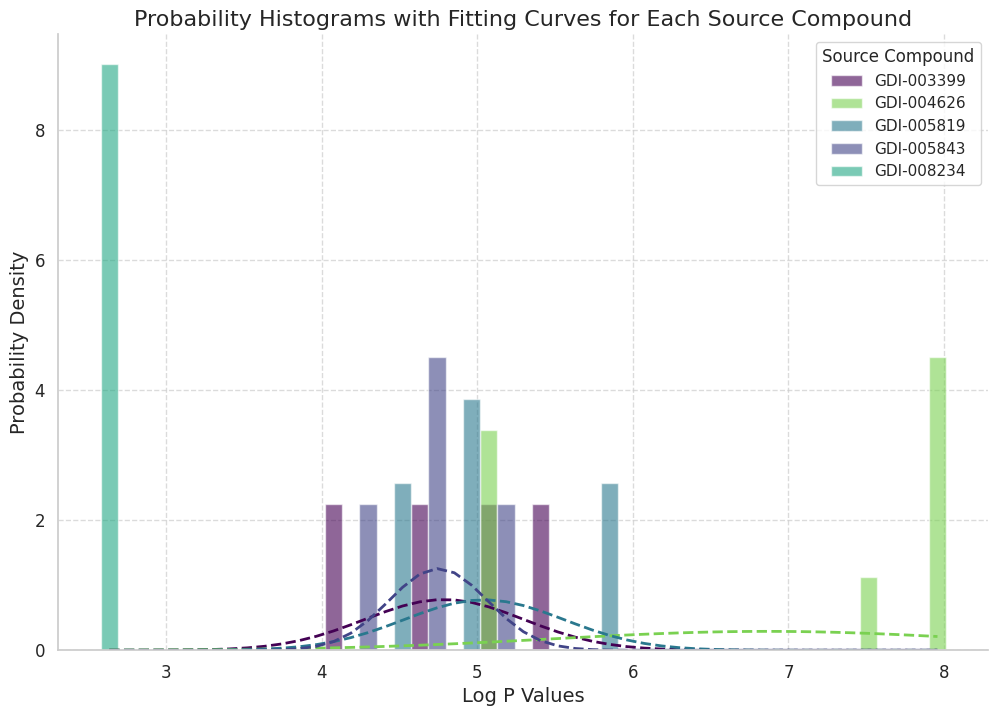

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns
import pandas as pd

# 为图表设置 seaborn 样式
sns.set(style="whitegrid")

# 读取CSV文件
df = al_rm  # 替换为您的文件路径

# 为图表设置字体大小
plt.rcParams['font.size'] = 10

# 准备一个足够大的bins数组用于所有数据
all_data = df['log_p'].dropna()  # 假设我们绘制'log_p'列的直方图
bins = np.linspace(all_data.min(), all_data.max(), 50)

# 创建一个颜色映射，用于不同source_cmpd
color_map = {unique_source: plt.cm.viridis(i / len(df['source_cmpd'].unique()))
             for i, unique_source in enumerate(df['source_cmpd'].unique())}

# 创建一个大的画布
plt.figure(figsize=(12, 8))

# 对每个source_cmpd绘制直方图和拟合曲线
for source, group_data in df.groupby('source_cmpd'):
    if 'log_p' in group_data.columns:  # 确保列存在
        # 计算直方图
        hist, bin_edges = np.histogram(group_data['log_p'], bins=bins, density=True)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        
        # 拟合正态分布并计算PDF值
        params = norm.fit(group_data['log_p'])
        pdf = norm.pdf(bin_centers, loc=params[0], scale=params[1])
        
        # 绘制直方图和拟合曲线
        plt.hist(bin_centers, bins, weights=hist, alpha=0.6, color=color_map[source], label=source)
        plt.plot(bin_centers, pdf * sum(hist) * (bin_edges[1] - bin_edges[0]), 
                 color=color_map[source], linestyle='--', linewidth=2)

# 添加网格线
plt.grid(True, linestyle='--', alpha=0.7)

# 添加标题和标签
plt.title('Probability Histograms with Fitting Curves for Each Source Compound', fontsize=16)
plt.xlabel('Log P Values', fontsize=14)
plt.ylabel('Probability Density', fontsize=14)

# 添加图例
plt.legend(title='Source Compound')

# 设置 x 轴和 y 轴的刻度字体大小
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# 移除图表上方和右侧的边框线
sns.despine()

# 展示图表
plt.savefig('/mnt/disk1/xueying/JAEGER/models/assays/Novartis_GNF/output/logp.jpg')
plt.show()


/home/xueying/anaconda3/envs/jaeger/lib/python3.9/site-packages/scipy/stats/_distn_infrastructure.py:1988: RuntimeWarning: divide by zero encountered in divide
  x = np.asarray((x - loc)/scale, dtype=dtyp)


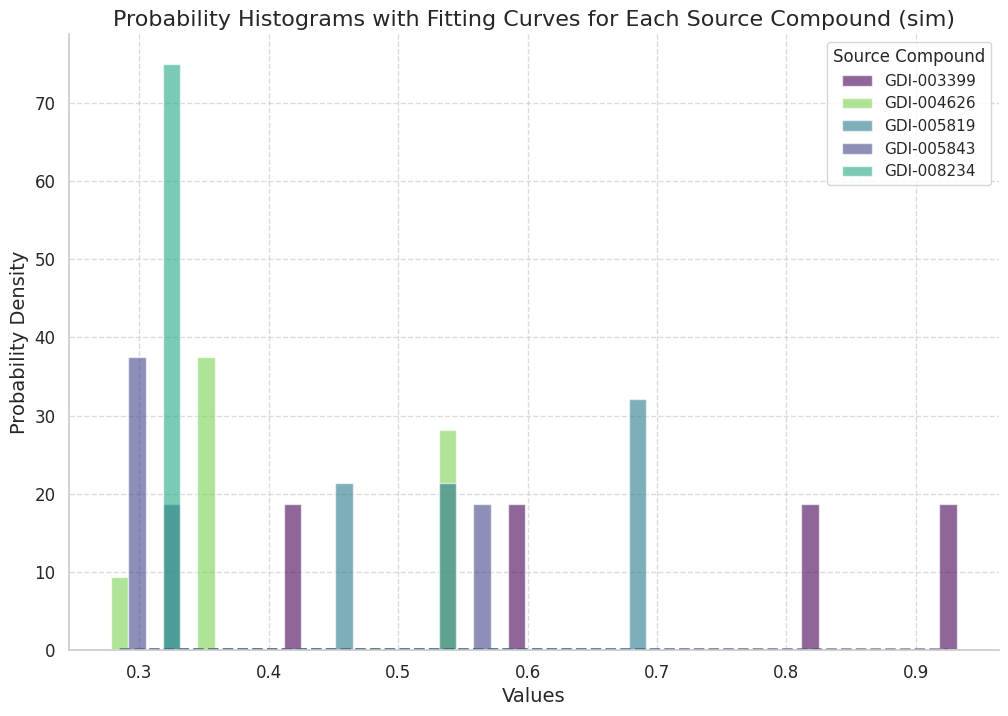

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns
import pandas as pd

# 为图表设置 seaborn 样式
sns.set(style="whitegrid")

# 读取CSV文件，假设您的DataFrame已经存储在变量al_rm中
# 如果不是，请将 al_rm 替换为您的CSV文件路径，并使用 pd.read_csv 来读取
df = al_rm  # 替换为您的文件路径

# 列名变量，您可以根据需要更改列名
column_name = 'sim'

# 为图表设置字体大小
plt.rcParams['font.size'] = 10

# 准备一个足够大的bins数组用于所有数据
all_data = df[column_name].dropna()
bins = np.linspace(all_data.min(), all_data.max(), 50)

# 创建一个颜色映射，用于不同source_cmpd
color_map = {unique_source: plt.cm.viridis(i / len(df['source_cmpd'].unique()))
             for i, unique_source in enumerate(df['source_cmpd'].unique())}

# 创建一个大的画布
plt.figure(figsize=(12, 8))

# 对每个source_cmpd绘制直方图和拟合曲线
for source, group_data in df.groupby('source_cmpd'):
    if column_name in group_data.columns:  # 确保列存在
        # 计算直方图
        hist, bin_edges = np.histogram(group_data[column_name], bins=bins, density=True)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        
        # 拟合正态分布并计算PDF值
        params = norm.fit(group_data[column_name])
        pdf = norm.pdf(bin_centers, loc=params[0], scale=params[1])
        
        # 绘制直方图和拟合曲线
        plt.hist(bin_centers, bins, weights=hist, alpha=0.6, color=color_map[source], label=source)
        plt.plot(bin_centers, pdf * (bin_edges[1] - bin_edges[0]), 
                 color=color_map[source], linestyle='--', linewidth=2)

# 添加网格线
plt.grid(True, linestyle='--', alpha=0.7)

# 添加标题和标签
plt.title(f'Probability Histograms with Fitting Curves for Each Source Compound ({column_name})', fontsize=16)
plt.xlabel('Values', fontsize=14)
plt.ylabel('Probability Density', fontsize=14)

# 添加图例
plt.legend(title='Source Compound', loc='best')

# 设置 x 轴和 y 轴的刻度字体大小
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# 移除图表上方和右侧的边框线
sns.despine()

# 保存图表到文件，包含列名
save_path = '/mnt/disk1/xueying/JAEGER/models/assays/Novartis_GNF/output/'
file_name = f'{column_name}_distribution_by_source_cmpd.jpg'
plt.savefig(f'{save_path}{file_name}')

# 展示图表
plt.show()

In [59]:
import src.cadd.sascorer as sascorer
import networkx as nx
# ------------ CHEMISTRY ROUTINES ------------
from rdkit.Chem import Descriptors, rdmolops
from rdkit.Chem.Descriptors import ExactMolWt


def get_cycle_score(mol):
    cycle_list = nx.cycle_basis(nx.Graph(rdmolops.GetAdjacencyMatrix(mol)))
    if len(cycle_list) == 0:
        cycle_length = 0
    else:
        cycle_length = max([len(j) for j in cycle_list])
    if cycle_length <= 6:
        cycle_length = 0
    else:
        cycle_length = cycle_length - 6
    current_cycle_score = cycle_length
    return current_cycle_score


import src.cadd.sascorer as sascorer
# toxdata should include a mols value
from rdkit.Chem import rdMolDescriptors
from rdkit.Chem.Descriptors import ExactMolWt

NumHDonors = lambda x: rdMolDescriptors.CalcNumHBD(x)
NumHAcceptors = lambda x: rdMolDescriptors.CalcNumHBA(x)
from rdkit.Chem import Descriptors

TPSA = lambda x: Descriptors.TPSA(x)

from rdkit import Chem


def compute_properties(toxdata):
    n_molecules = len(toxdata)
    k = 0
    mw = {}
    na = {}
    log_p = {}
    sas = {}
    cycle_scores = {}
    # more properties
    nhdon= {}
    nhacc = {}
    tpsa = {}
    toxdata['mols'] = toxdata['JC_XSMILES'].apply(lambda x: Chem.MolFromSmiles(x))
    
    for idx in toxdata.index:
        print_status(k, n_molecules)
        mol = toxdata.loc[idx].mols
        try:
            mw[idx] = ExactMolWt(mol)
            log_p[idx] = Descriptors.MolLogP(mol)
            sas[idx] = sascorer.calculateScore(mol)
            cycle_scores[idx] = get_cycle_score(mol)
            na[idx] = mol.GetNumAtoms()
            nhdon[idx] = NumHDonors(mol)
            nhacc[idx] = NumHAcceptors(mol)
            tpsa[idx] = TPSA(mol)
            
        except:
            print("[DEBUG] Error computing properties")
            mw[idx] = np.nan
            log_p[idx] = np.nan
            sas[idx] = np.nan
            cycle_scores[idx] = np.nan
            na[idx] = np.nan
            nhdon[idx] = np.nan
            nhacc[idx] = np.nan
            tpsa[idx]  = np.nan                                    
            continue
        k = k + 1

    props = [
        pd.DataFrame.from_dict(mw, orient="index"),
        pd.DataFrame.from_dict(log_p, orient="index"),
        pd.DataFrame.from_dict(sas, orient="index"),
        pd.DataFrame.from_dict(cycle_scores, orient="index"),
        pd.DataFrame.from_dict(na, orient="index"),
        pd.DataFrame.from_dict(nhdon, orient="index"),
        pd.DataFrame.from_dict(nhacc, orient="index"),
        pd.DataFrame.from_dict(tpsa, orient="index"),                
        
    ]

    props_df = pd.concat(props, axis=1)
    props_df.columns = ["mw", "log_p", "sas", "cycle_scores", "n_atoms","HBD",
                        "HBA",
                        "TPSA"]



    toxdata_props = pd.merge(toxdata, props_df, left_index=True, right_index=True)
    return toxdata_props

import sys
def print_status(i, maxSteps):
    percent = "0.00"
    percentage = (float(i) / float(maxSteps)) * 100
    divisor = 5
    if i % divisor == 0:
        sys.stdout.write("Progress: %d%%   \r" % (percentage))
        sys.stdout.flush()


In [27]:
train_prop = compute_properties(train)
train_prop.to_csv('/mnt/disk1/xueying/JAEGER/models/assays/Novartis_GNF/output/train_with_prop.csv', index = False)

In [77]:
import pandas as pd
train_prop = pd.read_csv('/mnt/disk1/xueying/JAEGER/models/assays/Novartis_GNF/output/train_with_prop.csv')
al_rm = pd.read_csv('/mnt/disk1/xueying/JAEGER/models/assays/Novartis_GNF/output/gen_merge_rmsource.csv')

In [78]:
al_rm.source_cmpd.value_counts()

source_cmpd
GNF-Pf-1210    95
GNF-Pf-2519    50
GNF-Pf-1945    36
GNF-Pf-4216    17
GNF-Pf-3788     9
Name: count, dtype: int64

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/disk1/xueying/JAEGER/models/assays/Novartis_GNF/output/train_molgen/log_p.jpg'

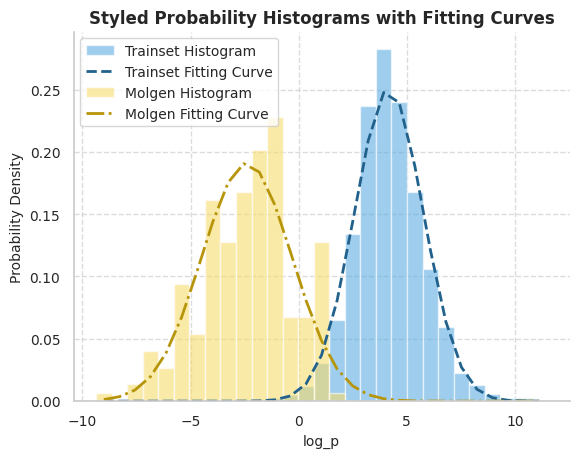

In [80]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

# 为图表设置 seaborn 样式
sns.set(style="whitegrid")

# 生成两组正态分布的随机数据
prop = 'log_p'
data1 = train_prop[prop].to_numpy()
data2 = al_rm[prop].to_numpy()

# 设置图表的字体大小
plt.rcParams['font.size'] = 12

# 计算两组数据的直方图和对应的密度函数
# bins = np.linspace(0, 150, 50)
bins = np.linspace(min(data1.min(), data2.min()), max(data1.max(), data2.max()), 30)
hist1, bins1 = np.histogram(data1, bins=bins, density=True)
hist2, bins2 = np.histogram(data2, bins=bins, density=True)
bin_centers1 = 0.5 * (bins1[1:] + bins1[:-1])
bin_centers2 = 0.5 * (bins2[1:] + bins2[:-1])

# 拟合两组数据到正态分布并获取PDF值
pdf1 = norm.pdf(bin_centers1, *norm.fit(data1))
pdf2 = norm.pdf(bin_centers2, *norm.fit(data2))

# Plot 直方图和拟合曲线
# plt.figure(figsize=(10, 6)) # 设置图表大小
plt.hist(data1, bins=bins, density=True, alpha=0.6, color='#5dade2', label='Trainset Histogram')
plt.plot(bin_centers1, pdf1, color='#21618c', linestyle='--', linewidth=2, label='Trainset Fitting Curve')

plt.hist(data2, bins=bins, density=True, alpha=0.6, color='#f7dc6f', label='Molgen Histogram')
plt.plot(bin_centers2, pdf2, color='#b7950b', linestyle='-.', linewidth=2, label='Molgen Fitting Curve')

# 添加图例，并指定大小
plt.legend(fontsize='small')

# 添加网格线
plt.grid(True, linestyle='--', alpha=0.7)

# 添加标题和标签
plt.title('Styled Probability Histograms with Fitting Curves', fontsize=12, fontweight='bold')
plt.xlabel(prop, fontsize=10)
plt.ylabel('Probability Density', fontsize=10)

# 设置 ticker 的样式
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# 移除上方和右侧的 spine
sns.despine()

# 展示图表
plt.savefig(f'/mnt/disk1/xueying/JAEGER/models/assays/Novartis_GNF/output/train_molgen/{prop}.jpg')
plt.show()

## novartis

In [1]:
train = pd.read_csv('/mnt/disk1/xueying/JAEGER/models/training_data/Novartis_GNF_rm_error_5251_v3.csv')
gen1210 = pd.read_csv('/mnt/disk1/xueying/JAEGER/models/assays/Novartis_GNF/jtvae/jtvae-h-420-l-56-d-7/genchem/GNF-Pf-1210/GNF-Pf-1210-dir-4-strategy-DeterministicFullGraph-extent-Dense-cutoff-0.2-filter-False-opt_direction-Increase-subset_pca-False.csv')
gen1945 = pd.read_csv('/mnt/disk1/xueying/JAEGER/models/assays/Novartis_GNF/jtvae/jtvae-h-420-l-56-d-7/genchem/GNF-Pf-1945/GNF-Pf-1945-dir-4-strategy-DeterministicFullGraph-extent-Dense-cutoff-0.2-filter-False-opt_direction-Increase-subset_pca-False.csv')
gen2519 = pd.read_csv('/mnt/disk1/xueying/JAEGER/models/assays/Novartis_GNF/jtvae/jtvae-h-420-l-56-d-7/genchem/GNF-Pf-2519/GNF-Pf-2519-dir-4-strategy-DeterministicFullGraph-extent-Dense-cutoff-0.2-filter-False-opt_direction-Increase-subset_pca-False.csv')
gen3788 = pd.read_csv('/mnt/disk1/xueying/JAEGER/models/assays/Novartis_GNF/jtvae/jtvae-h-420-l-56-d-7/genchem/GNF-Pf-3788/GNF-Pf-3788-dir-4-strategy-DeterministicFullGraph-extent-Dense-cutoff-0.2-filter-False-opt_direction-Increase-subset_pca-False.csv')
gen4216 = pd.read_csv('/mnt/disk1/xueying/JAEGER/models/assays/Novartis_GNF/jtvae/jtvae-h-420-l-56-d-7/genchem/GNF-Pf-4216/GNF-Pf-4216-dir-4-strategy-DeterministicFullGraph-extent-Dense-cutoff-0.2-filter-False-opt_direction-Increase-subset_pca-False.csv')

NameError: name 'pd' is not defined

In [3]:
import pandas as pd
gen1 = pd.read_csv('/mnt/disk1/xueying/JAEGER/models/assays/antimalaria/jtvae/jtvae-h-420-l-56-d-7/genchem/GDI-003399/GDI-003399-dir-4-strategy-DeterministicFullGraph-extent-Dense-cutoff-0.2-filter-False-opt_direction-Increase-subset_pca-False.csv')
gen2 = pd.read_csv('/mnt/disk1/xueying/JAEGER/models/assays/antimalaria/jtvae/jtvae-h-420-l-56-d-7/genchem/GDI-004626/GDI-004626-dir-4-strategy-DeterministicFullGraph-extent-Dense-cutoff-0.2-filter-False-opt_direction-Increase-subset_pca-False.csv')
gen3 = pd.read_csv('/mnt/disk1/xueying/JAEGER/models/assays/antimalaria/jtvae/jtvae-h-420-l-56-d-7/genchem/GDI-005819/GDI-005819-dir-4-strategy-DeterministicFullGraph-extent-Dense-cutoff-0.2-filter-False-opt_direction-Increase-subset_pca-False.csv')
gen4 = pd.read_csv('/mnt/disk1/xueying/JAEGER/models/assays/antimalaria/jtvae/jtvae-h-420-l-56-d-7/genchem/GDI-005843/GDI-005843-dir-4-strategy-DeterministicFullGraph-extent-Dense-cutoff-0.2-filter-False-opt_direction-Increase-subset_pca-False.csv')
gen5 = pd.read_csv('/mnt/disk1/xueying/JAEGER/models/assays/antimalaria/jtvae/jtvae-h-420-l-56-d-7/genchem/GDI-008234/GDI-008234-dir-4-strategy-DeterministicFullGraph-extent-Dense-cutoff-0.2-filter-False-opt_direction-Increase-subset_pca-False.csv')

In [6]:
gen1.shape, gen2.shape, gen3.shape, gen4.shape, gen5.shape

((9, 13), (9, 13), (8, 13), (5, 13), (2, 13))

In [7]:
al = pd.concat([gen1, gen2, gen3, gen4, gen5], ignore_index=True)
al.shape

(33, 13)

In [8]:
al

,Unnamed: 0,pac50,smiles,sim,mw,log_p,sas,cycle_scores,n_atoms,HBD,HBA,TPSA,source_cmpd
0,GDI-003399,4.774136,CNC(=O)C(Cc1ccc(-c2ccccc2O)cc1)n1c(=O)[nH]c2cc...,1.000000,534.226705,5.10114,3.021068,0,40,4,5,116.22,GDI-003399
1,GDI-003399-GC-001,5.499760,CNC(=O)[C@H](Cc1ccc(-c2ccccc2OC)cc1)n1c(=O)[nH...,0.588235,500.242356,4.06330,3.017028,0,37,3,5,105.22,GDI-003399
2,GDI-003399-GC-002,5.494394,CNC(=O)[C@@H](Cc1ccc(-c2ccccc2OC)cc1)n1c(=O)[n...,0.588235,500.242356,4.06330,3.017028,0,37,3,5,105.22,GDI-003399
3,GDI-003399-GC-003,5.446460,COc1ccccc1-c1ccc(C[C@@H](NC(=O)CNc2ccc(C)c(C)c...,0.418750,542.325691,4.57644,2.832301,0,40,3,5,82.70,GDI-003399
4,GDI-003399-GC-004,5.422475,COc1ccccc1-c1ccc(C[C@H](NC(=O)CNc2ccc(C)c(C)c2...,0.418750,542.325691,4.57644,2.832301,0,40,3,5,82.70,GDI-003399
5,GDI-003399-GC-005,5.266436,CNC(=O)[C@@H](Cc1ccc(-c2ccccc2OC)cc1)n1c(=O)[n...,0.817460,548.242356,5.40414,2.987378,0,41,3,5,105.22,GDI-003399
6,GDI-003399-GC-006,5.264545,CNC(=O)[C@H](Cc1ccc(-c2ccccc2OC)cc1)n1c(=O)[nH...,0.817460,548.242356,5.40414,2.987378,0,41,3,5,105.22,GDI-003399
7,GDI-003399-GC-007,4.782892,CNC(=O)[C@@H](Cc1ccc(-c2ccccc2O)cc1)n1c(=O)[nH...,0.931624,534.226705,5.10114,3.024822,0,40,4,5,116.22,GDI-003399
8,GDI-003399-GC-008,4.779709,CNC(=O)[C@H](Cc1ccc(-c2ccccc2O)cc1)n1c(=O)[nH]...,0.931624,534.226705,5.10114,3.024822,0,40,4,5,116.22,GDI-003399
9,GDI-004626,5.789504,CC1CC(C)(C)N(C)c2c1cc(-c1cnc(C(F)(F)F)nc1)c(O)...,1.000000,450.260646,5.52060,3.735404,0,32,2,5,61.28,GDI-004626


In [9]:
al.to_csv('/mnt/disk1/xueying/JAEGER/models/assays/antimalaria/output/gen_merge.csv')

In [10]:
al_rm = al[al['sim'] < 1]
al_rm.shape

(28, 13)

In [11]:
al_rm.to_csv('/mnt/disk1/xueying/JAEGER/models/assays/antimalaria/output/gen_merge_rmsource.csv', index=False)

In [60]:
train_prop = compute_properties(train)
train_prop.to_csv('/mnt/disk1/xueying/JAEGER/models/assays/Novartis_GNF/output/train_with_prop.csv', index = False)

In [61]:
al_rm.source_cmpd.value_counts()

source_cmpd
GNF-Pf-1210    95
GNF-Pf-2519    50
GNF-Pf-1945    36
GNF-Pf-4216    17
GNF-Pf-3788     9
Name: count, dtype: int64

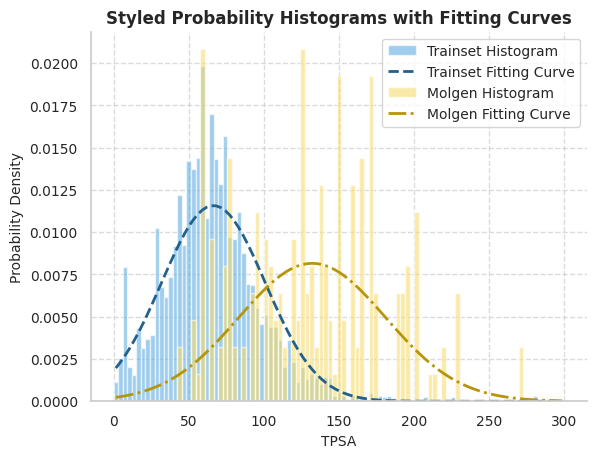

In [76]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

# 为图表设置 seaborn 样式
sns.set(style="whitegrid")

# 生成两组正态分布的随机数据
prop = 'TPSA'
data1 = train_prop[prop].to_numpy()
data2 = al_rm[prop].to_numpy()

# 设置图表的字体大小
plt.rcParams['font.size'] = 12

# 计算两组数据的直方图和对应的密度函数
bins = np.linspace(0, 300, 100)
# bins = np.linspace(min(data1.min(), data2.min()), max(data1.max(), data2.max()), 30)
hist1, bins1 = np.histogram(data1, bins=bins, density=True)
hist2, bins2 = np.histogram(data2, bins=bins, density=True)
bin_centers1 = 0.5 * (bins1[1:] + bins1[:-1])
bin_centers2 = 0.5 * (bins2[1:] + bins2[:-1])

# 拟合两组数据到正态分布并获取PDF值
pdf1 = norm.pdf(bin_centers1, *norm.fit(data1))
pdf2 = norm.pdf(bin_centers2, *norm.fit(data2))

# Plot 直方图和拟合曲线
# plt.figure(figsize=(10, 6)) # 设置图表大小
plt.hist(data1, bins=bins, density=True, alpha=0.6, color='#5dade2', label='Trainset Histogram')
plt.plot(bin_centers1, pdf1, color='#21618c', linestyle='--', linewidth=2, label='Trainset Fitting Curve')

plt.hist(data2, bins=bins, density=True, alpha=0.6, color='#f7dc6f', label='Molgen Histogram')
plt.plot(bin_centers2, pdf2, color='#b7950b', linestyle='-.', linewidth=2, label='Molgen Fitting Curve')

# 添加图例，并指定大小
plt.legend(fontsize='small')

# 添加网格线
plt.grid(True, linestyle='--', alpha=0.7)

# 添加标题和标签
plt.title('Styled Probability Histograms with Fitting Curves', fontsize=12, fontweight='bold')
plt.xlabel(prop, fontsize=10)
plt.ylabel('Probability Density', fontsize=10)

# 设置 ticker 的样式
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# 移除上方和右侧的 spine
sns.despine()

# 展示图表
plt.savefig(f'/mnt/disk1/xueying/JAEGER/models/assays/Novartis_GNF/output/{prop}.jpg')
plt.show()

### merge trainset

In [1]:
import pandas as pd
gh = pd.read_csv('/mnt/disk1/xueying/tmp/antimalaria/trainset_v3.csv')
nov = pd.read_csv('/mnt/disk1/xueying/JAEGER/models/training_data/Novartis_GNF_rm_error_5251_v3.csv')

In [2]:
gh.shape, nov.shape

((1681, 4), (5251, 4))

In [3]:
gh.head()

,CompoundID,Cleaned_SMILES,Operator,Value
0,GDI-000912-001,Cc1ccc(C2(NC(=O)C3CNCC3c3cc(F)c(C(F)(F)F)c(F)c...,=,9.0
1,GDI-001022-001,Cc1ccc(C2(NC(=O)C3C(C)NCC3c3ccc(C(F)(F)F)c(Cl)...,=,39.0
2,GDI-001276-001,Cc1ccc(C2(NC(=O)C3C(=O)NCC3c3ccc(C(F)(F)F)c(Cl...,=,50.0
3,GDI-001297-001,Cc1ccc(C2(NC(=O)C3CNCC3c3ccc(C(F)(F)F)c(F)c3)C...,=,7.0
4,GDI-001298-001,Cc1ccc(C2(NC(=O)C3CNC3c3ccc(C(F)(F)F)cc3)CC2)cc1,=,8331.0


In [4]:
nov.head()

,GNF-Pf identifier,JC_XSMILES,Qualifier,PF proliferation inhibition 3D7 EC50 uM
0,GNF-Pf-1034,COC1=C2OC3=C(OC)C(OC)=CC4=C3C(CC5=CC=C(O)C(OC6...,NaN,0.99700
1,GNF-Pf-104,NC1=NC(N)=C2C=C(C=CC2=N1)S(=O)(=O)N3CCCCC3,NaN,0.02017
2,GNF-Pf-1042,COC1=CC2=C(C=C1OC)C(=O)N(NC(=O)C3=CC=CC(F)=C3)...,NaN,1.25000
3,GNF-Pf-1046,C=CCC1(CCCCC1)NC2=CC=CC=C2,NaN,1.25000
4,GNF-Pf-1064,FC1=CC=CC=C1NC2=NC(NCC3=CC=CC=C3)=C4C=CC=CC4=N2,NaN,0.46300


In [6]:
gh['PF proliferation inhibition 3D7 EC50 uM'] = gh['Value'] / 1000

In [8]:
gh.drop(['Value'], axis=1, inplace=True)

In [9]:
gh

,CompoundID,Cleaned_SMILES,Operator,PF proliferation inhibition 3D7 EC50 uM
0,GDI-000912-001,Cc1ccc(C2(NC(=O)C3CNCC3c3cc(F)c(C(F)(F)F)c(F)c...,=,0.0090
1,GDI-001022-001,Cc1ccc(C2(NC(=O)C3C(C)NCC3c3ccc(C(F)(F)F)c(Cl)...,=,0.0390
2,GDI-001276-001,Cc1ccc(C2(NC(=O)C3C(=O)NCC3c3ccc(C(F)(F)F)c(Cl...,=,0.0500
3,GDI-001297-001,Cc1ccc(C2(NC(=O)C3CNCC3c3ccc(C(F)(F)F)c(F)c3)C...,=,0.0070
4,GDI-001298-001,Cc1ccc(C2(NC(=O)C3CNC3c3ccc(C(F)(F)F)cc3)CC2)cc1,=,8.3310
...,...,...,...,...
1676,GDI-006441-001,Cc1ccc(S(=O)(=O)CCNC(=O)c2c(-c3c(F)cccc3F)noc2...,=,50.0000
1677,GDI-006442-001,Cc1ccc(S(=O)(=O)CCNC(=O)c2c(-c3ccccn3)noc2C)cc1,=,50.0000
1678,GDI-006443-001,Cc1ccc(S(=O)(=O)CCNC(=O)c2c(-c3c(C)cccc3C)noc2...,=,15.6554
1679,GDI-006444-001,Cc1ccc(S(=O)(=O)CCNC(=O)c2c(-c3c(Cl)cccc3Cl)nc...,=,50.0000


In [14]:
# 直接在原始DataFrame上重命名列，不返回新的DataFrame
l = nov.columns.tolist()
l
# gd = gh.rename(columns=nov.columns.tolist(), inplace=True)

['GNF-Pf identifier',
 'JC_XSMILES',
 'Qualifier',
 'PF proliferation inhibition 3D7 EC50 uM']

In [15]:
data = pd.read_csv('/mnt/disk1/xueying/tmp/nov_gh/Novartis_GHDDI_6932_v1.csv')

In [16]:
data.shape

(6932, 4)

In [19]:
data.head()

,CompoundID,Cleaned_SMILES,Operator,Value
0,GNF-Pf-1034,COC1=C2OC3=C(OC)C(OC)=CC4=C3C(CC5=CC=C(O)C(OC6...,=,0.99700
1,GNF-Pf-104,NC1=NC(N)=C2C=C(C=CC2=N1)S(=O)(=O)N3CCCCC3,=,0.02017
2,GNF-Pf-1042,COC1=CC2=C(C=C1OC)C(=O)N(NC(=O)C3=CC=CC(F)=C3)...,=,1.25000
3,GNF-Pf-1046,C=CCC1(CCCCC1)NC2=CC=CC=C2,=,1.25000
4,GNF-Pf-1064,FC1=CC=CC=C1NC2=NC(NCC3=CC=CC=C3)=C4C=CC=CC4=N2,=,0.46300


In [18]:
data['Operator'] = '='

In [21]:
data.to_csv('/mnt/disk1/xueying/tmp/nov_gh/Novartis_GHDDI_6932_v1.csv', index=False)